---
Lesson 3
---

Within this weeks lesson, we are going to learn an important algorithm which can be used in more advanced cryptography work, however I am going to try and keep it simple. Then we will look at how to find the modular inverse of a number, which can be used to break an affine cipher. Lastly, we will look at a method which can be used to break any monoalphabetic substitution cipher (which include shift ciphers and affine ciphers).

# Section 1: Euclids Algorithm

### Who is Euclid?

We will start with a little bit of history about Euclid. Euclid was an ancient Greek Mathematician, who is known as the 'father of geometry' due to his study of shapes. He was the first Mathematician who wrote things called 'axioms', which you can think of as rules that Maths has to follow. This means he was very important to the development of Mathematics. I would recommend having a little read about him (https://en.wikipedia.org/wiki/Euclid).

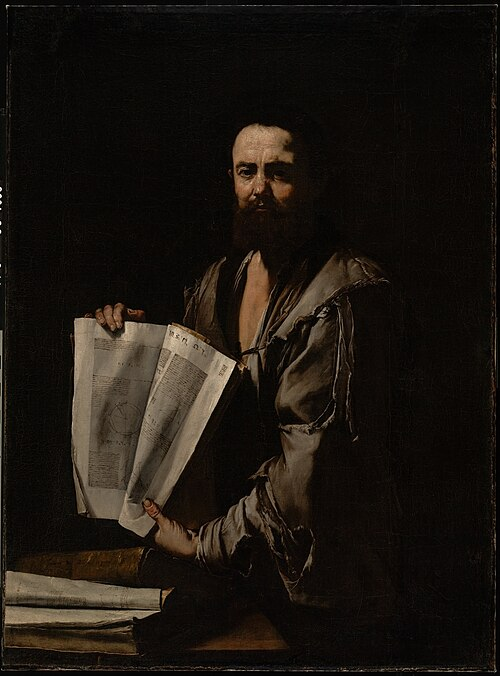

In [3]:
#| echo: false
#| label: Euclid
#| caption: Here is a painting of what we think Euclid looks like.
from IPython.display import Image, display
display(Image(filename='Euclid.jpg'))

### What is an algorithm?
'Algorithm'='алгоритм'<br>
An algorithm is a set of instructions which are used to solve a specific problem. They are quite common in Computer Science and Mathematics. You can think of it as like a cooking recipe, if you follow all the instructions correctly and have all the right ingredients, then you will get some wonderful food.

### What is Euclids Algorithm?
Euclids algorithm is used to find the greatest common divisor between two numbers. So far we have only used small numbers. For example, we can easily see that the greatest common divisor between 27 and 33 is 3. However, as we use larger numbers, it is going to be harder to find their prime factors meaning it's harder to find their greatest common divisors. Just as a reminder, if the greatest common divisor of two numbers $x$ and $y$ is $z$, then I would write $gcd(x,y)=z$. For example, $gcd(27,33)=3$.

If I asked you to find the greatest common divisor of 10302 and 21726, you might find the answer but it would take a lot of time. Euclids algorithm gives you a quick method. However, before looking at $gcd(10302,21726)$, we are going to use an easier example to get you familiar with the algorithm.

Before we start the examples, I would like to credit this youtube video (https://www.youtube.com/watch?v=Jwf6ncRmhPg). This is the video explains Euclids algorithm very well, and it's what gave me the idea to represent Euclids algorithm in the way that you're about to see in the examples. So give it a watch after doing the examples.

### Example 1

For this example, each slide represents one of the steps below, so click through the slides and read what they mean at each step.

Find $gcd(78,102)$ using Euclids Algorithm.

Steps:

1. First, I want you to imagine that we have got each number in its own area, like what is being shown in the diagram. We can see that there is 78 dots on the left, and 102 dots on the right.
2. We then look at whichever area has the most amount of dots in, and take away the number of dots from the other side as many times as we can. For this example, we can only take 78 away from 102 once, because if we did it twice then we would have a negative number.
3. You then write out the new number of dots that you have in each side. We now have 78 does on the left side, and 24 dots on the right side (as $102-78=24$).
4. We then repeat step 2. We can see that now 78 is the side with the most dots, so we take away 24 from 78 for as many times as we can. We take three lots of 24 away from 78, because if we took 4 lots away, then we would have a negative number.
5. We now have 6 dots on the left side, and 24 dots on the right side.
6. We can now do our last step, and take away 4 lots of 6 from the right side, to leave us with zero.
7. We are left with 6 and 0, meaning that the greatest common divisor of 78 and 102 is 6. Our answer is $gcd(78,102)=6$.

```{=html}
<div class="Euclid-widget">
  <img id="ft-image" src="Euclidfolder/Euclid1.png" alt="Euclid step">
  <div class="ft-controls">
    <button id="ft-back">◀ Back</button>
    <span id="ft-counter">Step 1 of 7</span>
    <button id="ft-next">Next ▶</button>
  </div>
</div>

<style>
.Euclid-widget {
  max-width: 600px;
  margin: 1.5rem auto;
  text-align: center;
}
.Euclid-widget img {
  width: 100%;
  border: 1px solid #ddd;
  border-radius: 8px;
}
.ft-controls {
  margin-top: 0.75rem;
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 1rem;
}
.ft-controls button {
  padding: 0.4rem 1rem;
  font-size: 1rem;
  cursor: pointer;
  border: 1px solid #ccc;
  border-radius: 6px;
  background: #f5f5f5;
}
.ft-controls button:disabled {
  opacity: 0.4;
  cursor: not-allowed;
}
</style>

<script>
(function() {
  const totalSteps = 7;
  let currentStep = 1;
  const img = document.getElementById('ft-image');
  const counter = document.getElementById('ft-counter');
  const backBtn = document.getElementById('ft-back');
  const nextBtn = document.getElementById('ft-next');

  function render() {
    img.src = `Euclidfolder/Euclid${currentStep}.png`;
    counter.textContent = `Step ${currentStep} of ${totalSteps}`;
    backBtn.disabled = currentStep === 1;
    nextBtn.disabled = currentStep === totalSteps;
  }

  backBtn.addEventListener('click', () => {
    if (currentStep > 1) { currentStep--; render(); }
  });
  nextBtn.addEventListener('click', () => {
    if (currentStep < totalSteps) { currentStep++; render(); }
  });

  render();
})();
</script>
```

Now that you have seen an example, it's time for me to explain some things. 
- The number on the left and the number on the right will always have the same greatest common divisor.
- One of the ways the algorithm ends is by getting a zero in one of the areas. This means that the $gcd$ is equal to whatever number is in the other box.
- The other way the algorithm ends is by getting a one in one of the areas. This means that the $gcd$ of the two numbers is equal to one (hence the numbers are coprime).

We will now look at an example where the two numbers are coprime, so you can see what happens.

### Example 2

Similar to the last example, please click through the slideshow and read through the steps so you know what is happening on each slide.

Find $gcd(82,65)$ using Euclids Algorithm.

Steps:

1. Write our two numbers in their two seperate areas.
2. Notice that 82 is the larger number, so we take away 65 from 82 as many times as we can before we get a negative number. We only take 65 away once, because if we took it away twice then we would get a negative number.
3. Our new numbers are 17 and 65.
4. We can see that 65 is now the larger number so we take away 17 from 65. This time, we can only take 17 away from 65 3 times before getting a negative number.
5. Now we are left with 17 and 14.
6. 17 is our larger number, so we take 14 away from it.
7. We are left with 3 and 14.
8. 14 is our larger number, so we take 3 away from it.
9. We are left with 3 and 2.
10. 3 is our larger number so we take 2 away from it.
11. We are left with 1 and 2. I said earlier that the algorithm ends when we get either a 1 or a zero, and now that we have a 1, we end our algorithm.

```{=html}
<div class="Euclid-widget-2">
  <img id="ft-image-2" src="Euclidfolder2/Euclid21.png" alt="Euclid step">
  <div class="ft-controls2">
    <button id="ft-back-2">◀ Back</button>
    <span id="ft-counter-2">Step 1 of 11</span>
    <button id="ft-next-2">Next ▶</button>
  </div>
</div>
<style>
.Euclid-widget-2 {
  max-width: 600px;
  margin: 1.5rem auto;
  text-align: center;
}
.Euclid-widget-2 img {
  width: 100%;
  border: 1px solid #ddd;
  border-radius: 8px;
}
.ft-controls2 {
  margin-top: 0.75rem;
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 1rem;
}
.ft-controls2 button {
  padding: 0.4rem 1rem;
  font-size: 1rem;
  cursor: pointer;
  border: 1px solid #ccc;
  border-radius: 6px;
  background: #f5f5f5;
}
.ft-controls2 button:disabled {
  opacity: 0.4;
  cursor: not-allowed;
}
</style>
<script>
(function() {
  const totalSteps = 11;
  let currentStep = 1;
  const img = document.getElementById('ft-image-2');
  const counter = document.getElementById('ft-counter-2');
  const backBtn = document.getElementById('ft-back-2');
  const nextBtn = document.getElementById('ft-next-2');
  function render() {
    img.src = `Euclidfolder2/Euclid2${currentStep}.png`;
    counter.textContent = `Step ${currentStep} of ${totalSteps}`;
    backBtn.disabled = currentStep === 1;
    nextBtn.disabled = currentStep === totalSteps;
  }
  backBtn.addEventListener('click', () => {
    if (currentStep > 1) { currentStep--; render(); }
  });
  nextBtn.addEventListener('click', () => {
    if (currentStep < totalSteps) { currentStep++; render(); }
  });
  render();
})();
</script>
```

For this example, we can see that we get 1 as one of our final numbers. This means that $gcd(82,65)=1$, so 82 and 65 are coprime. 

When you see these examples, you might think to yourself that I am doing a lot of work for these questions, and you would be right. I am showing you every step that is needed to get the correct answer. However, once you have some practice with these questions then you will be able to do them a lot quicker. In example 2, at step 5 we had 17 and 14 in our two boxes. If you remember that the greatest common divisor of the two numbers in the boxes will always be the same, then you can realise that $gcd(82,65)=gcd(17,14)$. You might also notice that 17 is a prime number, and the greatest common divisor between a prime number and any other number (except the prime itself) is equal to 1. So you would have been able to stop the algorithm after the 5th step as you would already know that the two numbers had a greatest common divisor of one.

Anyway, it's time for one last example, but this time we are going to use some big numbers to show you how useful this algorithm is.

### Example 3

Find $gcd(10302,21726)$ using Euclids Algorithm.

As you can see these numbers are quite large, and I do not have the time to create a diagram with twenty thousand dots in, so we are going to do this without a diagram. The algorithm will stay exactly the same, only you will not have the visual help. If you are struggling to understand what is happening without the diagrams, then I recommend having a go at some of the easier practice questions first, then come back to this example.

The first thing we are going to do is take away the smaller number from the larger number as many times as possible. We can see that $21726$ is larger than $10302$, so we will do: $$21726-2 \times 10302 = 1122$$

Our new numbers are now, $10302$ and $1122$. This means that we do: $$10302- 9 \times 1122=204$$

Our new numbers are now, $204$ and $1122$. We now carry on the process and take the smaller number away from the larger one: $$1122- 5 \times 204 = 102$$

Now we have our two numbers as $204$ and $102$. Lastly, we can see that: $$204 - 2 \times 102 = 0$$ Meaning that the algorithm ends because we have got a zero.

Our final answer is that $gcd(10302,21726)=102$. I hope you can appreciate that without Euclids algorithm, it would have been very difficult to spot that $102$ is a factor of both $10302$ and $21726$, which shows you how useful this algorithm is.

Some of you may have realised that at the begining I said an algorithm was a set of instructions to solve a problem, however I never explicitly gave you the instructions for this algorithm. I did this because I did not want to confuse you, as it does look a bit difficult if you have never seen it before. Hopefully now you are familiar with some examples, you will be able to understand the instructions easier. The instructions are as follows:

1. Start with two numbers $x$ and $y$ where $x \geq y > 0 $.
2. Divide $x$ by $y$ to get two numbers $q$ and $r$ such that: $$x = y \times q + r$$ Where $0 \leq r < y$.
3. Check the remainder:
   - if $r=0$, then $y$ is the greatest common divisor.
   - if $r$ is not equal to zero, replace $x$ with $y$ and $y$ with $r$, then go back to step 2.

Also, according to these instructions, you only end the algorithm if you have zero as one of you numbers, however I said that you end the algorithm if you have either a zero or a one. Both of these methods will work, because if you see a $1$ as one of your numbers, then you know on the next step you will have a zero anyways (because every number, $n$, can be wrote as $n = n \times 1$), so my method saves a little bit of time.

Hopefully, you're familiar with this algorithm now, as it is time for some practice questions!

# Practice questions: Euclids algorithm

1. Use a diagram to find $gcd(12,26)$ using Euclids algorithm.
2. Find $gcd(90,135)$ using Euclids algorithm.
3. Find $gcd(60515,26460)$ using Euclids algorithm.
4. The *Dictionary of Chinese Varient Form* complied by the Taiwan Ministry of Eduction in 2004 contains 106,230 indicidual characters. I want to create an affine cipher using this alphabet. I have chosen $\alpha = 85547$. Will this give me a valid affine cipher? Explain why.

# Section 2: How to break an affine cipher

In this section we will be looking at some rather difficult Maths, as we will be adding to our knowledge of Euclids Algorithm by introducing the Extended Euclidian Algorithm. We will also introduce the concept of multiplicative modular inverses (I know it sounds scary, but trust me when I say that it's not that bad).

### What is a multiplicative inverse?

Every number has a multiplicative inverse. If I have a number $x$, then its multiplicative inverse is the number $y$ such that: $$x \times y = 1$$

For normal numbers (when we are not using mod), this is very easy to calculate. For example, the multiplicative inverse of $2$ is $\frac{1}{2}$. We can check this and see that: $$2 \times \frac{1}{2} = 1$$

The multiplicative inverse of $60$ is $\frac{1}{60}$, because: $$60 \times \frac{1}{60} = 1$$

The multiplicative inverse of $-\frac{1}{5}$ is $-5$, because: $$-\frac{1}{5} \times -5 = 1$$

I could carry on doing these examples, but I think you probably get the idea. For any number $x$, the multiplicative inverse is $\frac{1}{x}$, so you don't even need to do any Maths, you can simply write the same number underneath $1$ in a fraction.

For a little bit more information, 'multiplicative' means that we are multiplying the numbers together (as you can probably guess), and 'inverse' means that they equal one. If you study Maths futher you will find that this links heavily with group theory, however we will not look at that now (maybe I will do a course on it if you are interested).

You can also say that if we have some number $x$, then its modular inverse is $x^{-1}$ such that: $$x \times x^{-1} = 1$$ This is exactly the same as the other definition, only I have swapped $y$ with $x^{-1}$.

### What is a multiplicative modular inverse?


Note that for this section I have used $\text{mod 26}$ for the examples, however they will still work if you use another number.

Similar to the last part, we still need two numbers to multiply together to equal one, however the difference is that now we are using modular arithmetic. If I have a number $x$, then its multiplicative modular inverse under modulo $26$ is the number $y$ such that: $$x \times y = 1 \text{ (mod 26)}$$

It can sometimes be very difficult to find the number $y$, however we have some tricks we can use.

First, we know that $\text{mod}$ is hard to deal with, so we need to find a way to get rid of it. We can remember that when we have $\text{mod 26}$ at the end of an equation, all it means is that we are adding (or subtracking) some multiple of $26$ from either side of the equation. This means that we do this:$$x \times y = 1 \text{ (mod 26)} \implies x \times y + 26 \times n = 1$$ where $n$ is just an integer.

Please take some time to make sure that you understand the step above. We are quickly going to pause this example because we need to understand the Extended Euclidian Algorithm first. Don't worry though, as we will come back to this.

### What is the Extended Euclidian Algorithm?
The Extended Euclidian Algorithm is an algorithm used to find $gcd(a,b)$ of two numbers $a$ and $b$, then it finds the integers $x$ and $y$ such that: $$a \times x + b \times y = gcd(a,b)$$

The first thing to notice is that the first half of this algorithm is exactly the same as the Euclidian Algorithm! The Euclidian Algorithm is used to find the greatest common divisor of two number $a$ and $b$, so you already know how to use half of this algorithm. We will now look at this algorithm in an example.

### Example 1

Use the Extended Euclidian Algorithm on the numbers $35$ and $29$. 

The first half of this algorithm is just the Euclidian Algorithm, and we know how that works. Using Euclids algorithm, we get: $$35=29 \times 1 + 6$$ $$29= 6 \times 4 + 5$$ $$6 = 5 \times 1 + 1 $$ $$5 = 1 \times 5 + 0$$

The algorithm has finished with $0$ and $1$ being the final numbers. This shows that $gcd(35,29)=1$, so $35$ and $29$ are coprime.

We use Euclids Algorithm to change two large numbers into smaller numbers while keeping the $gcd$ between the numbers the same. This makes it easier to work out the $gcd$. <br>With the Extended Euclidian Algorithm, we change smaller numbers into larger numbers, while still requiring the difference between the numbers to be equal to one.

In the slideshow below, I will be getting a lot of equations our of seemingly knowwhere. However, all of the equations I get are simply the ones above but they have been rearranged. This is why we need to do the Euclidian Algorithm first. Rearranging the equations above, we can get:$$35=29 \times 1 + 6 \implies 35 - 29 \times 1 = 6$$ $$29= 6 \times 4 + 5 \implies 29 - 6 \times 4 = 5$$ $$6 = 5 \times 1 + 1 \implies 6-5 \times 1 =1$$

This next slideshow now goes through the Extended Euclidian Algorithm for this specific example. I have used a lot of slides to break it up into smaller parts making it easier to understand.

```{=html}
<div class="Euclid-widget-3">
  <img id="ft-image-3" src="ExEuclidfolder/ExEuclid1.png" alt="Euclid step">
  <div class="ft-controls3">
    <button id="ft-back-3">◀ Back</button>
    <span id="ft-counter-3">Step 1 of 25</span>
    <button id="ft-next-3">Next ▶</button>
  </div>
</div>
<style>
.Euclid-widget-3 {
  max-width: 600px;
  margin: 1.5rem auto;
  text-align: center;
}
.Euclid-widget-3 img {
  width: 100%;
  border: 1px solid #ddd;
  border-radius: 8px;
}
.ft-controls3 {
  margin-top: 0.75rem;
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 1rem;
}
.ft-controls3 button {
  padding: 0.4rem 1rem;
  font-size: 1rem;
  cursor: pointer;
  border: 1px solid #ccc;
  border-radius: 6px;
  background: #f5f5f5;
}
.ft-controls3 button:disabled {
  opacity: 0.4;
  cursor: not-allowed;
}
</style>
<script>
(function() {
  const totalSteps = 25;
  let currentStep = 1;
  const img = document.getElementById('ft-image-3');
  const counter = document.getElementById('ft-counter-3');
  const backBtn = document.getElementById('ft-back-3');
  const nextBtn = document.getElementById('ft-next-3');
  function render() {
    img.src = `ExEuclidfolder/ExEuclid${currentStep}.png`;
    counter.textContent = `Step ${currentStep} of ${totalSteps}`;
    backBtn.disabled = currentStep === 1;
    nextBtn.disabled = currentStep === totalSteps;
  }
  backBtn.addEventListener('click', () => {
    if (currentStep > 1) { currentStep--; render(); }
  });
  nextBtn.addEventListener('click', () => {
    if (currentStep < totalSteps) { currentStep++; render(); }
  });
  render();
})();
</script>
```

This give us our final equation of: $$35 \times 5 - 29 \times 6 =1 $$

This tells us that: $$35 \times 5 - 29 \times 6 = 1 \implies 29 \times 6 =1 \text{ (mod 35)}$$

Now we are going to look at another example, this time in the context of an affine cipher.